# 02 — Vegetation and Ground Materials

Two more layers the SDK can pull for any polygon:

- `client.vegetation.get_area(polygon)` -- street trees as GeoJSON points,
  each with species/height/canopy attributes when available.
- `client.ground_materials.get_area(polygon)` -- surface coverage layers
  (asphalt, concrete, soil, water, vegetation, building footprints) as
  GeoJSON `FeatureCollection`s, one per material.

Both feed into the thermal analyses (UTCI, TCS) and the daylight / solar
radiation analyses, so it's worth knowing what you're sending.

In [1]:
from dotenv import load_dotenv
load_dotenv()

from infrared_sdk import InfraredClient
from cities import get

# Vienna's Rathauspark has a good mix of buildings, paths, lawn and water,
# so all ground-material layers come back populated.
city = get("vienna")
print(f"City: {city.name}")

City: Vienna


## Fetch trees

In [2]:
with InfraredClient() as client:
    veg = client.vegetation.get_area(city.polygon_small)

print(f"total_trees : {veg.total_trees}")
sample_id, sample_feat = next(iter(veg.features.items()))
print(f"\nsample id   : {sample_id}")
print(f"sample feat : {sample_feat}")

total_trees : 1250

sample id   : node/2044235966
sample feat : {'type': 'Feature', 'id': 'node/2044235966', 'geometry': {'type': 'Point', 'coordinates': [16.358297, 48.209321]}, 'properties': {'natural': 'tree', 'leaf_type': 'broadleaved', 'leaf_cycle': None, 'height': '3', 'circumference': '0.15', 'diameter_crown': '0.5', 'species': 'Carpinus betulus'}}


Each value is a standard GeoJSON `Feature` with a `Point` geometry in
WGS-84 lat/lon and any tags from the OSM source (height, species, etc.).

## Fetch ground materials

In [3]:
with InfraredClient() as client:
    gm = client.ground_materials.get_area(city.polygon_small)

print(f"total_features  : {gm.total_features}")
print(f"layers present  : {list(gm.layers)}")
for name, fc in gm.layers.items():
    print(f"  {name:12s}: {len(fc.get('features', []))} features")

total_features  : 31
layers present  : ['asphalt', 'building', 'concrete', 'vegetation', 'soil', 'water']
  asphalt     : 1 features
  building    : 0 features
  concrete    : 13 features
  vegetation  : 16 features
  soil        : 0 features
  water       : 1 features


## Visualise everything together

Plot tree positions on top of the surface layers so you can see how the
two map onto each other.

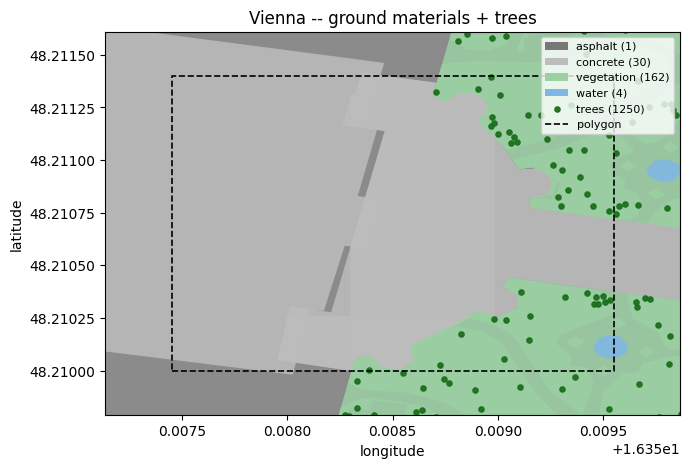

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon, Patch
from matplotlib.collections import PatchCollection

_COLORS = {
    "vegetation": "#9bd0a3",
    "water":      "#7eb6e8",
    "asphalt":    "#777777",
    "concrete":   "#bdbdbd",
    "soil":       "#caa472",
    "building":   "#e8a85a",
}

fig, ax = plt.subplots(figsize=(7, 7))
legend_handles = []
for name, fc in gm.layers.items():
    patches = []
    for feat in fc.get("features", []):
        geom = feat.get("geometry", {})
        rings = []
        if geom.get("type") == "Polygon":
            rings = [geom.get("coordinates", [[]])[0]]
        elif geom.get("type") == "MultiPolygon":
            rings = [p[0] for p in geom.get("coordinates", [])]
        for ring in rings:
            if ring:
                patches.append(MplPolygon([(p[0], p[1]) for p in ring], closed=True))
    if patches:
        color = _COLORS.get(name, "#bbb")
        ax.add_collection(PatchCollection(
            patches, facecolor=color, edgecolor="none", alpha=0.85))
        # PatchCollection labels don't auto-register; use a proxy patch instead.
        legend_handles.append(Patch(facecolor=color, label=f"{name} ({len(patches)})"))

lons, lats = [], []
for feat in veg.features.values():
    coords = (feat.get("geometry") or {}).get("coordinates", [])
    if len(coords) >= 2:
        lons.append(coords[0]); lats.append(coords[1])
if lons:
    sc = ax.scatter(lons, lats, s=14, c="#1b6f1b", alpha=0.95,
                    label=f"trees ({len(lons)})")
    legend_handles.append(sc)

poly = city.polygon_small["coordinates"][0]
px = [p[0] for p in poly]
py = [p[1] for p in poly]
outline, = ax.plot(px, py, "k--", lw=1.2, label="polygon")
legend_handles.append(outline)

# Zoom tight to the polygon plus a small margin so we actually see the data
# inside it instead of the API's tile-aligned buffer.
mx = (max(px) - min(px)) * 0.15
my = (max(py) - min(py)) * 0.15
ax.set_xlim(min(px) - mx, max(px) + mx)
ax.set_ylim(min(py) - my, max(py) + my)

ax.set_aspect("equal")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"{city.name} -- ground materials + trees")
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Passing layers to analyses

Pass the dicts directly to `run_area_and_wait` -- the orchestrator
handles per-tile dedup and assignment:

```python
result = client.run_area_and_wait(
    [payload],
    polygon,
    buildings=area.buildings,
    vegetation=veg.features,           # all trees
    ground_materials=gm.layers,        # all surface layers
)
```

If a layer is empty or you don't have it, pass `{}` (or omit the
keyword). See the README's "Layer parameter behaviour" section for the
full table of cases.

> **Size watchout.** Ground materials can be heavy in dense
> neighbourhoods. If `gm.total_features > ~5000`, consider down-sampling
> or skipping the layer to avoid HTTP 413.

Next: `03_weather_and_time_periods.ipynb`.